# Capstone Project - EDA: Ames Housing (House Prices)
## Phân tích đơn biến (Univariate Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('train.csv')
df.shape

(1460, 81)

## 1. Phân phối biến mục tiêu: SalePrice

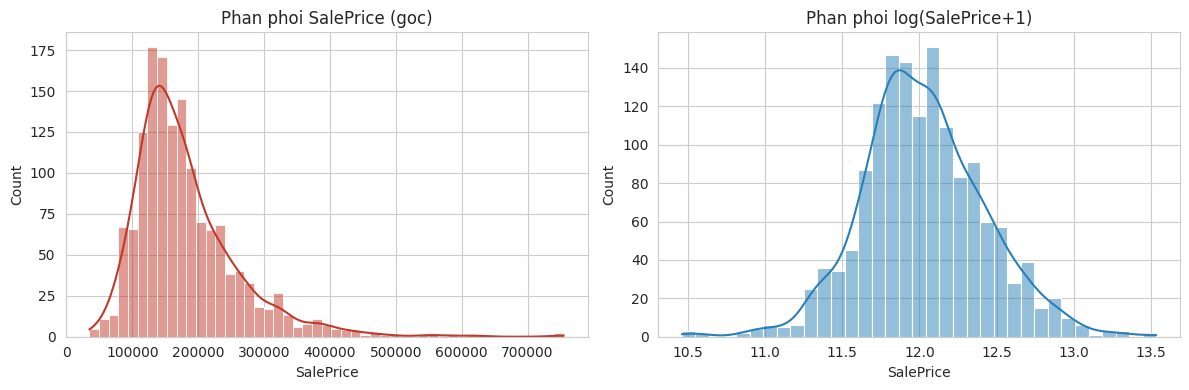

Skew goc: 1.883 | Skew sau log: 0.121


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#c0392b')
axes[0].set_title('Phân phối SalePrice (gốc)')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='#2980b9')
axes[1].set_title('Phân phối log(SalePrice+1)')
plt.tight_layout()
plt.show()
print("Skew goc:", round(df['SalePrice'].skew(),3), "| Skew sau log:", round(np.log1p(df['SalePrice']).skew(),3))

In [ ]:
print("Độ lệch SalePrice trước log:", round(df['SalePrice'].skew(), 3))
print("Độ lệch SalePrice sau log:", round(np.log1p(df['SalePrice']).skew(), 3))


**Nhận xét:** `SalePrice` lệch phải khá rõ (skew khoảng 1.88). Sau khi lấy log, phân phối cân đối hơn và độ lệch giảm xuống gần 0.12. Vì vậy, khi xây dựng mô hình có thể cân nhắc dự đoán `log(SalePrice)` thay vì dùng `SalePrice` trực tiếp.


## 2. Phân phối các biến số quan trọng

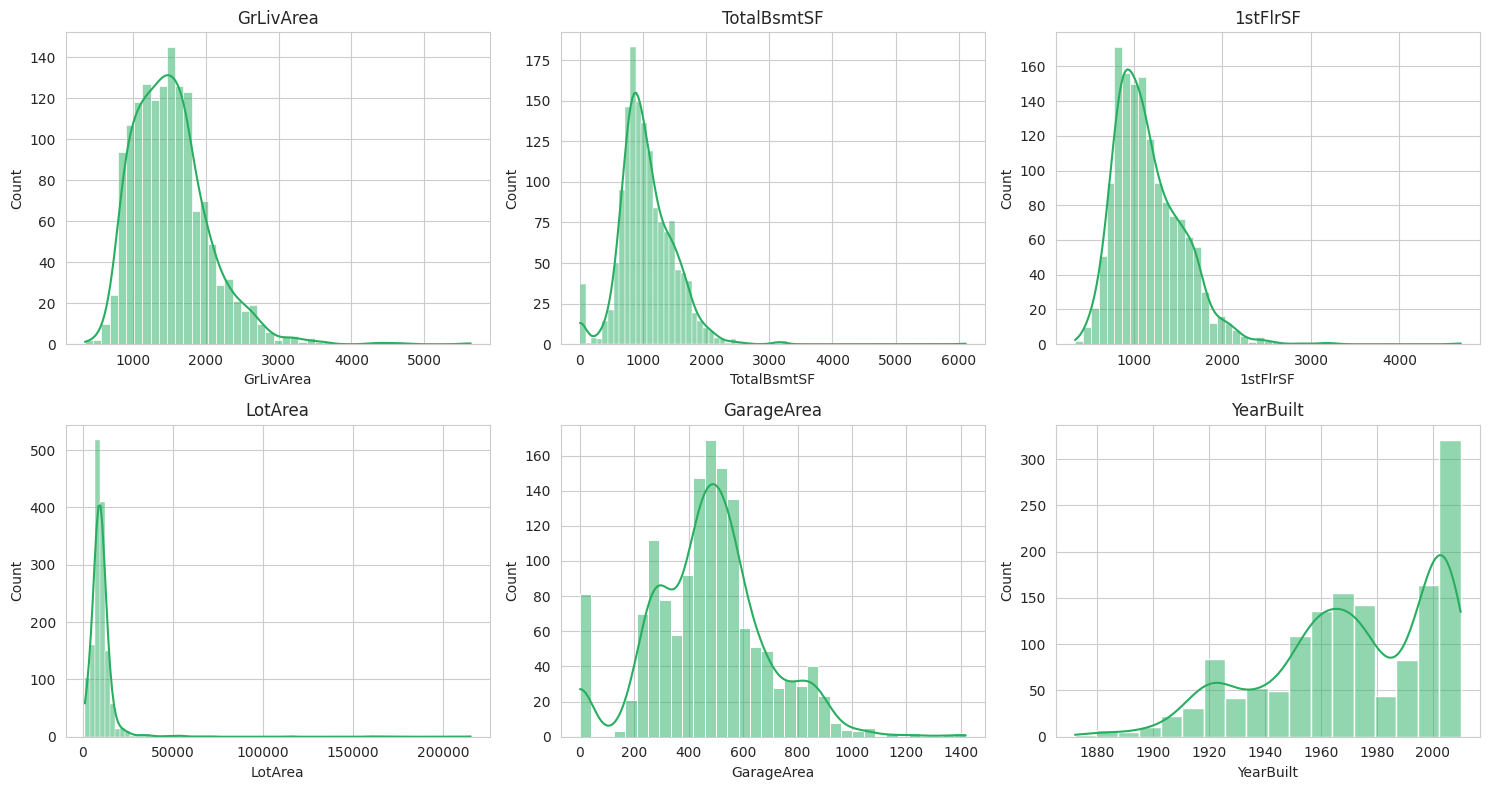

In [3]:
num_features = ['GrLivArea','TotalBsmtSF','1stFlrSF','LotArea','GarageArea','YearBuilt']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flatten(), num_features):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#27ae60')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Nhận xét:**
- `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `LotArea` đều lệch phải. Phần lớn nhà có diện tích vừa phải, một số ít nhà có diện tích rất lớn làm đuôi phân phối kéo dài sang phải.
- `YearBuilt` cho thấy số lượng nhà xây tăng dần theo thời gian và tập trung khá nhiều ở các năm gần đây của bộ dữ liệu.
- `GarageArea` có một lượng lớn giá trị bằng 0, tương ứng với những nhà không có garage.


## 3. Phân phối biến rời rạc dạng thứ bậc: OverallQual

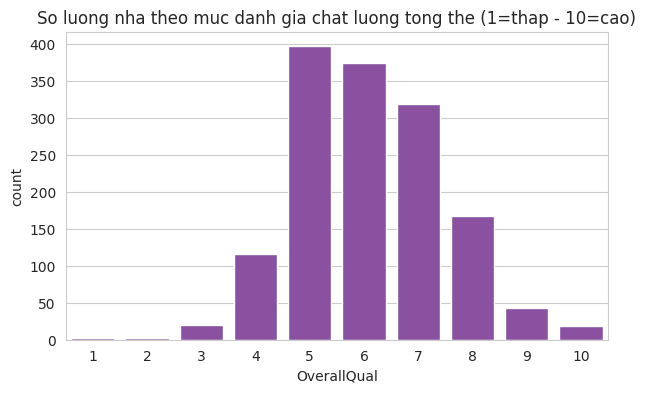

OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(7,4))
sns.countplot(x='OverallQual', data=df, color='#8e44ad')
plt.title('Số lượng nhà theo mức đánh giá chất lượng tổng thể (1=thấp - 10=cao)')
plt.show()
df['OverallQual'].value_counts().sort_index()

## 4. Các biến phân loại (categorical) quan trọng

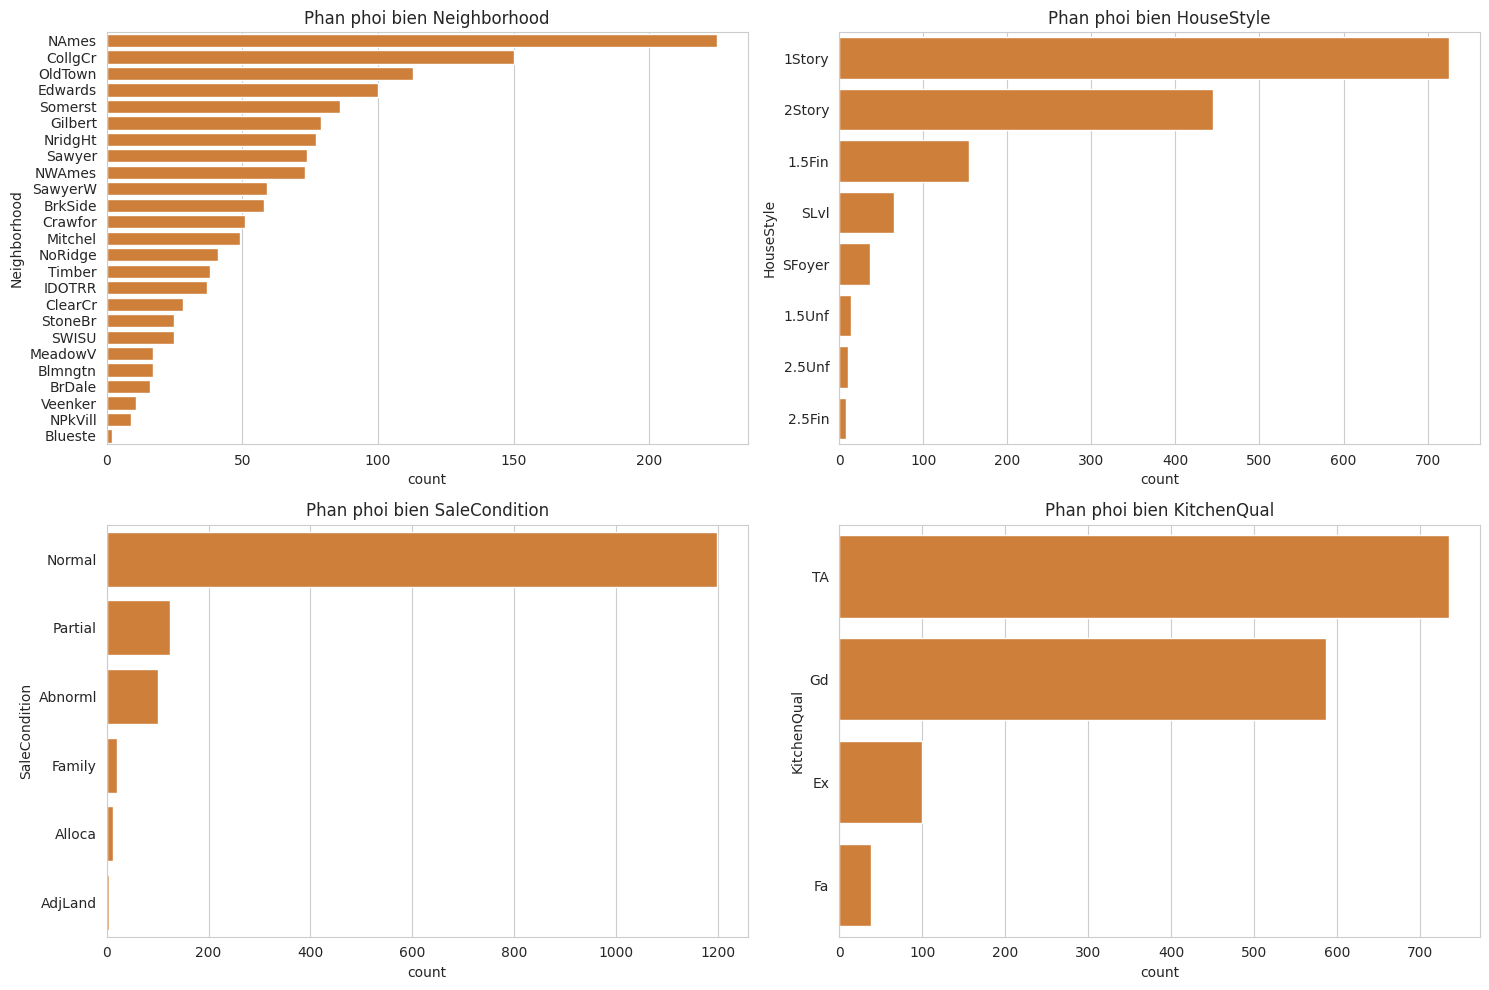

In [5]:
cat_features = ['Neighborhood','HouseStyle','SaleCondition','KitchenQual']
fig, axes = plt.subplots(2, 2, figsize=(15,10))
for ax, col in zip(axes.flatten(), cat_features):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax, color='#e67e22')
    ax.set_title(f'Phân phối biến {col}')
plt.tight_layout()
plt.show()

In [6]:
print("Top 5 khu vực (Neighborhood) có nhiều nhà nhất:")
print(df['Neighborhood'].value_counts().head(5))
print("\nĐiều kiện bán (SaleCondition) phổ biến nhất:")
print(df['SaleCondition'].value_counts())

Top 5 khu vuc (Neighborhood) nhieu nha nhat:
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Name: count, dtype: int64

Dieu kien ban (SaleCondition) pho bien nhat:
SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64


**Nhận xét:**
- `Neighborhood`: **NAmes**, **CollgCr**, **OldTown** là 3 khu vực có nhiều giao dịch nhất.
- `HouseStyle`: kiểu nhà **1 tầng (1Story)** và **2 tầng (2Story)** chiếm đa số.
- `SaleCondition`: phần lớn giao dịch là **Normal** (mua bán thông thường), phần còn lại là các trường hợp đặc biệt như **Partial** và **Abnorml**.
- `KitchenQual`: chất lượng nhà bếp phổ biến nhất là mức **Trung bình (TA)** và **Khá (Gd)**.


## 5. Kết luận

- Biến mục tiêu `SalePrice` và nhiều biến diện tích đều **lệch phải**, nên có thể log-transform trước khi mô hình hóa.
- Phần lớn nhà trong dữ liệu có chất lượng tổng thể (`OverallQual`) ở mức trung bình đến khá, tập trung khoảng 5-7/10.
- Ba khu vực NAmes, CollgCr, OldTown chiếm tỷ trọng giao dịch lớn; phần lớn giao dịch có `SaleCondition = Normal`.
